# Đánh giá mCLIP đã finetune (LoRA)
Notebook này **chỉ để load checkpoint đã train và tính Recall@K**, không train lại gì.

**Trước khi chạy, bạn cần add 2 input dataset vào notebook này:**
1. Dataset ảnh COCO + file CSV caption gốc (giống notebook train)
2. Dataset chứa 3 file checkpoint: `adapter_config.json` + `model.safetensors` (LoRA adapter) và `dense_weights.pth`

Sửa đúng các đường dẫn ở **Cell 2** cho khớp với nơi bạn upload.

In [1]:
#1
# ====== CELL ĐẦU TIÊN — chạy ngay sau khi Restart Kernel ======
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"   # phải set TRƯỚC khi import bất kỳ package HF nào

!pip uninstall -y hf_xet hf-xet -q
!pip install -q open_clip_torch peft sentence-transformers

print("Đã tắt Xet CDN, sẵn sàng chạy tiếp.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 84.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but 

In [2]:
#2
# ====== SỬA CÁC ĐƯỜNG DẪN NÀY CHO KHỚP VỚI INPUT CỦA BẠN ======

# --- Dữ liệu gốc (ảnh + CSV caption, giống hệt notebook train) ---
CSV_PATH = "/kaggle/input/datasets/js042710/final-datasets-tolora/final_coco_19k_dataset.csv"

# --- Checkpoint đã finetune (3 file bạn tải về từ notebook train) ---
# Cấu trúc mong đợi trong dataset checkpoint:
#   .../lora_weights/adapter_config.json
#   .../lora_weights/model.safetensors   (hoặc adapter_model.safetensors)
#   .../dense_weights.pth
LORA_DIR   = "/kaggle/input/datasets/js042710/lora-weights"
DENSE_PATH = "/kaggle/input/datasets/js042710/lora-weights/dense_weights.pth"

# --- Model gốc (kiến trúc + image encoder), tự tải, không cần sửa ---
BASE_MCLIP_NAME  = "sentence-transformers/clip-ViT-B-32-multilingual-v1"
LOCAL_BASE_PATH  = "/kaggle/working/clip-multilingual"
IMAGE_MODEL_NAME = "ViT-B-32-quickgelu"
IMAGE_PRETRAINED = "openai"

VAL_FRACTION = 0.05   # phải khớp với tỉ lệ đã dùng lúc train (5%) để so sánh công bằng
VAL_SEED = 42          # phải khớp seed lúc train, để tái tạo đúng tập val cũ

print("Đã set path xong, kiểm tra lại các path trên trước khi chạy tiếp.")

Đã set path xong, kiểm tra lại các path trên trước khi chạy tiếp.


In [3]:
#3
# ====== Load Image Encoder gốc (đóng băng) ======
import torch
import open_clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(IMAGE_MODEL_NAME, pretrained=IMAGE_PRETRAINED)
model = model.to(DEVICE)
model.visual.eval()
for p in model.visual.parameters():
    p.requires_grad = False

print("✅ Đã load Image Encoder (đóng băng).")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ Đã load Image Encoder (đóng băng).


In [4]:
#3.5
import os
import json
import shutil

# Đường dẫn dataset đang bị nhầm file config
src_dir = "/kaggle/input/datasets/js042710/lora-weights"
# Thư mục mới để chứa model chuẩn
LORA_DIR = "/kaggle/working/lora_weights_fixed"

# 1. Copy thư mục sang /working/ để có quyền chỉnh sửa
if not os.path.exists(LORA_DIR):
    shutil.copytree(src_dir, LORA_DIR)

# 2. ĐỔI TÊN FILE TRỌNG SỐ (Cực kỳ quan trọng, thiếu sẽ báo lỗi HFValidationError)
old_model = os.path.join(LORA_DIR, "model.safetensors")
new_model = os.path.join(LORA_DIR, "adapter_model.safetensors")
if os.path.exists(old_model):
    os.rename(old_model, new_model)
    print("✅ Đã đổi tên file safetensors thành công!")

# 3. Xóa file config.json bị sai 
wrong_config = os.path.join(LORA_DIR, "config.json")
if os.path.exists(wrong_config):
    os.remove(wrong_config)

# 4. Tạo lại file adapter_config.json CHUẨN 100%
correct_lora_config = {
    "peft_type": "LORA",
    "base_model_name_or_path": "sentence-transformers/clip-ViT-B-32-multilingual-v1",
    "bias": "none",
    "fan_in_fan_out": False,
    "inference_mode": True,
    "init_lora_weights": True,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "r": 16,
    "target_modules": ["q_lin", "k_lin", "v_lin", "out_lin"],
    "task_type": None
}

config_path = os.path.join(LORA_DIR, "adapter_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(correct_lora_config, f, indent=2)

print(f"✅ Đã dọn dẹp và tạo cấu hình LoRA chuẩn tại: {config_path}")

✅ Đã đổi tên file safetensors thành công!
✅ Đã dọn dẹp và tạo cấu hình LoRA chuẩn tại: /kaggle/working/lora_weights_fixed/adapter_config.json


In [5]:
#4
# ====== Load kiến trúc mCLIP gốc + gắn LoRA adapter + Dense đã train ======
import os
from sentence_transformers import SentenceTransformer
from transformers import AutoModel
from peft import PeftModel

# 1. Tải kiến trúc gốc (chỉ cần cấu trúc + tokenizer, KHÔNG phải trọng số đã finetune)
if not os.path.exists(LOCAL_BASE_PATH):
    os.system("git lfs install")
    os.system(f"git clone https://huggingface.co/{BASE_MCLIP_NAME} {LOCAL_BASE_PATH}")

# 2. Load base transformer rồi gắn LoRA adapter đã train vào
base_transformer = AutoModel.from_pretrained(LOCAL_BASE_PATH)
peft_transformer = PeftModel.from_pretrained(base_transformer, LORA_DIR)

# 3. Build lại SentenceTransformer, thay Transformer + Dense bằng bản đã train
finetuned_mclip = SentenceTransformer(LOCAL_BASE_PATH)
finetuned_mclip[0].auto_model = peft_transformer
finetuned_mclip[2].load_state_dict(torch.load(DENSE_PATH, map_location=DEVICE))
finetuned_mclip = finetuned_mclip.to(DEVICE).eval()
finetuned_tokenizer = finetuned_mclip[0].tokenizer

# 4. Load thêm BASELINE (mCLIP gốc, chưa finetune) để so sánh mức độ cải thiện
baseline_mclip = SentenceTransformer(LOCAL_BASE_PATH).to(DEVICE).eval()
baseline_tokenizer = baseline_mclip[0].tokenizer

print("✅ Đã load xong: baseline_mclip (gốc) và finetuned_mclip (đã LoRA).")

Git LFS initialized.


Cloning into '/kaggle/working/clip-multilingual'...
Filtering content: 100% (16/16), 4.90 GiB | 87.65 MiB/s, done.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.transformer.layer.0.attention.q_lin.lora_A.default.weight', 'base_model.model.transformer.layer.0.attention.q_lin.lora_B.default.weight', 'base_model.model.transformer.layer.0.attention.k_lin.lora_A.default.weight', 'base_model.model.transformer.layer.0.attention.k_lin.lora_B.default.weight', 'base_model.model.transformer.layer.0.attention.v_lin.lora_A.default.weight', 'base_model.model.transformer.layer.0.attention.v_lin.lora_B.default.weight', 'base_model.model.transformer.layer.0.attention.out_lin.lora_A.default.weight', 'base_model.model.transformer.layer.0.attention.out_lin.lora_B.default.weight', 'base_model.model.transformer.layer.1.attention.q_lin.lora_A.default.weight', 'base_model.model.transformer.layer.1.attention.q_lin.lora_B.default.weight', 'base_model.model.transformer.layer.1.attention.k_lin.lora_A.default.weight', 'ba

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Đã load xong: baseline_mclip (gốc) và finetuned_mclip (đã LoRA).


In [6]:
#5
# ====== Đọc CSV + tái tạo ĐÚNG tập validation đã dùng lúc train (cùng seed, cùng tỉ lệ) ======
import numpy as np
import pandas as pd

df = pd.read_csv(CSV_PATH)
df["full_path"] = df["image_dir"].str.rstrip("/") + "/" + df["file_name"]

rng = np.random.RandomState(VAL_SEED)
unique_ids = df["image_id"].unique()
rng.shuffle(unique_ids)

n_val = max(1, int(len(unique_ids) * VAL_FRACTION))
val_ids = set(unique_ids[:n_val])

val_df = df[df["image_id"].isin(val_ids)].reset_index(drop=True)
print(f"Tập validation: {len(val_df)} caption | {len(val_ids)} ảnh")
print("⚠️ Nếu số ảnh/caption ở đây khác hẳn lúc train, kiểm tra lại CSV_PATH/VAL_SEED/VAL_FRACTION có đúng như lúc train không.")

Tập validation: 6751 caption | 950 ảnh
⚠️ Nếu số ảnh/caption ở đây khác hẳn lúc train, kiểm tra lại CSV_PATH/VAL_SEED/VAL_FRACTION có đúng như lúc train không.


In [7]:
#6
# ====== Encode ảnh validation bằng Image Encoder đóng băng (chỉ encode phần val, không cần full dataset) ======
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

val_unique_images = val_df.drop_duplicates(subset="image_id")[["image_id", "full_path"]].reset_index(drop=True)

class ImageOnlyDataset(Dataset):
    def __init__(self, image_ids, image_paths, preprocess):
        self.image_ids = image_ids
        self.image_paths = image_paths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.preprocess(img), self.image_ids[idx]

val_img_dataset = ImageOnlyDataset(
    val_unique_images["image_id"].tolist(),
    val_unique_images["full_path"].tolist(),
    preprocess,
)
val_img_loader = DataLoader(val_img_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

image_embeddings = {}
with torch.no_grad():
    for imgs, ids in tqdm(val_img_loader, desc="Encoding validation images"):
        imgs = imgs.to(DEVICE)
        feats = model.visual(imgs).float().cpu()
        for i, img_id in enumerate(ids):
            image_embeddings[int(img_id)] = feats[i]

print(f"Đã encode {len(image_embeddings)} ảnh validation.")

Encoding validation images:   0%|          | 0/4 [00:00<?, ?it/s]

Đã encode 950 ảnh validation.


In [8]:
#7
# ====== Hàm tính Recall@K (text->image và image->text) ======
import torch.nn.functional as F

@torch.no_grad()
def evaluate_recall(mclip, tokenizer, val_df, image_embeddings, device, k_list=(1, 5, 10)):
    mclip.eval()
    val_unique_ids = val_df["image_id"].unique().tolist()
    id_to_idx = {img_id: i for i, img_id in enumerate(val_unique_ids)}

    image_feats = torch.stack([image_embeddings[i] for i in val_unique_ids]).to(device)
    image_feats = F.normalize(image_feats, dim=-1)

    captions = val_df["caption"].astype(str).tolist()
    caption_img_idx = [id_to_idx[i] for i in val_df["image_id"].tolist()]

    text_feats = []
    batch_size = 128
    for i in range(0, len(captions), batch_size):
        batch_caps = captions[i:i+batch_size]
        text_inputs = tokenizer(batch_caps, padding=True, truncation=True, max_length=77, return_tensors="pt")
        text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
        features = dict(text_inputs)
        for module in mclip:
            features = module(features)
        text_feats.append(features["sentence_embedding"].cpu())
    text_feats = torch.cat(text_feats).to(device)
    text_feats = F.normalize(text_feats, dim=-1)

    caption_img_idx_t = torch.tensor(caption_img_idx, device=device)

    sim_t2i = text_feats @ image_feats.t()
    ranks_t2i = sim_t2i.argsort(dim=-1, descending=True)
    results = {}
    for k in k_list:
        topk = ranks_t2i[:, :k]
        correct = (topk == caption_img_idx_t.unsqueeze(1)).any(dim=1).float().mean().item()
        results[f"text2image_R@{k}"] = correct * 100

    sim_i2t = image_feats @ text_feats.t()
    ranks_i2t = sim_i2t.argsort(dim=-1, descending=True)
    caption_img_idx_np = np.array(caption_img_idx)
    for k in k_list:
        correct = 0
        topk = ranks_i2t[:, :k].cpu().numpy()
        for img_idx in range(len(val_unique_ids)):
            gt_caption_idxs = np.where(caption_img_idx_np == img_idx)[0]
            if len(set(topk[img_idx]) & set(gt_caption_idxs)) > 0:
                correct += 1
        results[f"image2text_R@{k}"] = correct / len(val_unique_ids) * 100

    return results

print("Đã định nghĩa xong hàm evaluate_recall.")

Đã định nghĩa xong hàm evaluate_recall.


In [9]:
#8
# ====== Tính metrics: BASELINE vs FINETUNED ======
print("=== BASELINE (mCLIP gốc, chưa finetune) ===")
baseline_metrics = evaluate_recall(baseline_mclip, baseline_tokenizer, val_df, image_embeddings, DEVICE)
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.2f}")

print("\n=== FINETUNED (sau LoRA) ===")
finetuned_metrics = evaluate_recall(finetuned_mclip, finetuned_tokenizer, val_df, image_embeddings, DEVICE)
for k, v in finetuned_metrics.items():
    print(f"  {k}: {v:.2f}")

print("\n=== CHÊNH LỆCH (finetuned - baseline) ===")
for k in baseline_metrics:
    diff = finetuned_metrics[k] - baseline_metrics[k]
    print(f"  {k}: {diff:+.2f}")

=== BASELINE (mCLIP gốc, chưa finetune) ===
  text2image_R@1: 42.69
  text2image_R@5: 73.65
  text2image_R@10: 84.36
  image2text_R@1: 64.53
  image2text_R@5: 90.42
  image2text_R@10: 94.63

=== FINETUNED (sau LoRA) ===
  text2image_R@1: 47.65
  text2image_R@5: 78.36
  text2image_R@10: 88.99
  image2text_R@1: 67.58
  image2text_R@5: 90.53
  image2text_R@10: 94.84

=== CHÊNH LỆCH (finetuned - baseline) ===
  text2image_R@1: +4.96
  text2image_R@5: +4.71
  text2image_R@10: +4.64
  image2text_R@1: +3.05
  image2text_R@5: +0.11
  image2text_R@10: +0.21


🔍 Đang tìm kiếm cho câu: 'ngôi nhà'


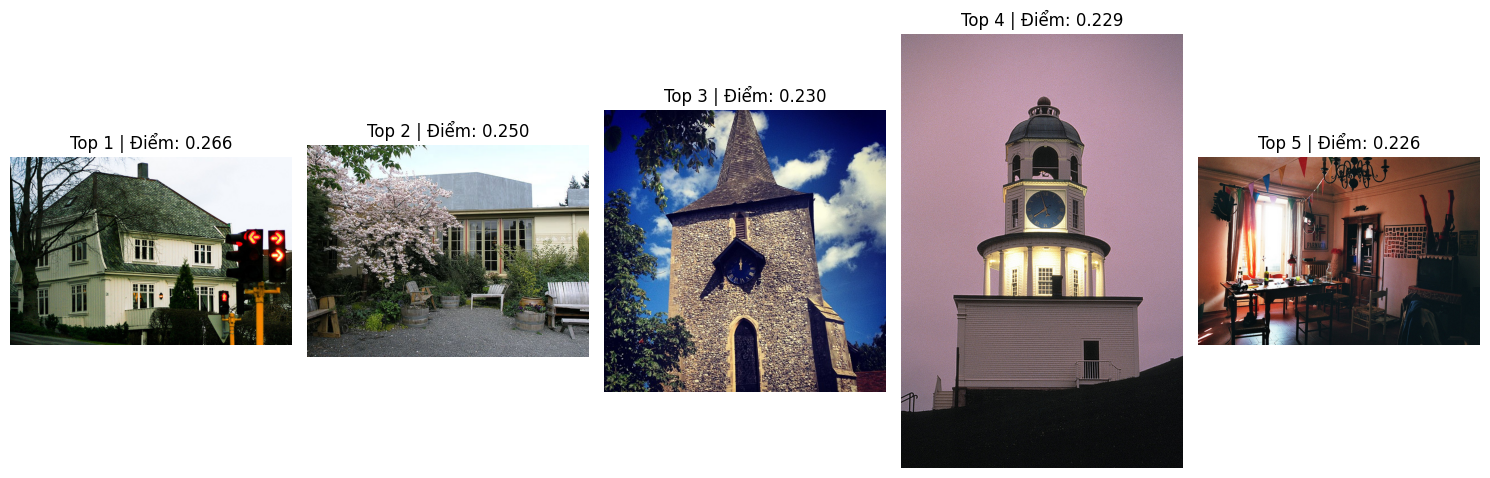

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# 1. GOM TOÀN BỘ VECTOR ẢNH THÀNH 1 MA TRẬN ĐỂ TÌM KIẾM CHO NHANH
search_image_ids = list(image_embeddings.keys())
search_image_feats = torch.stack([image_embeddings[i] for i in search_image_ids]).to(DEVICE)
search_image_feats = F.normalize(search_image_feats, dim=-1)

# Tạo từ điển map từ image_id sang đường dẫn file ảnh để lát hiển thị
id_to_path = dict(zip(df["image_id"], df["full_path"]))

# 2. ĐỊNH NGHĨA HÀM TÌM KIẾM BẰNG TEXT
def search_image_by_text(query, top_k=5):
    print(f"🔍 Đang tìm kiếm cho câu: '{query}'")
    finetuned_mclip.eval()
    
    with torch.no_grad():
        # Encode câu text thành vector
        text_inputs = finetuned_tokenizer([query], padding=True, truncation=True, max_length=77, return_tensors="pt")
        text_inputs = {k: v.to(DEVICE) for k, v in text_inputs.items()}
        
        features = dict(text_inputs)
        for module in finetuned_mclip:
            features = module(features)
        text_feat = features["sentence_embedding"]
        text_feat = F.normalize(text_feat, dim=-1)
        
        # Tính độ tương đồng (Cosine Similarity) giữa câu query và TẤT CẢ ảnh
        similarities = (text_feat @ search_image_feats.t()).squeeze(0)
        
        # Lấy ra top_k ảnh có điểm cao nhất
        top_scores, top_indices = similarities.topk(top_k)
        
    # 3. HIỂN THỊ KẾT QUẢ RA MÀN HÌNH
    plt.figure(figsize=(15, 5))
    for i, (score, idx) in enumerate(zip(top_scores, top_indices)):
        img_id = search_image_ids[idx.item()]
        img_path = id_to_path[img_id]
        
        # Đọc và hiển thị ảnh
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, top_k, i+1)
        plt.imshow(img)
        plt.title(f"Top {i+1} | Điểm: {score.item():.3f}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# ====== GÕ CÂU BẠN MUỐN TEST VÀO ĐÂY ======
# Vì là model multilingual nên bạn gõ tiếng Việt, tiếng Anh, hay tiếng gì nó cũng hiểu nhé!
search_image_by_text("ngôi nhà", top_k=5)